In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import tkinter as tk

In [19]:
df = pd.read_csv("health_data_1000.csv")
df.head()

,ID,Name,Gender,Age,BMI,Health_Issues,Smoker,Region,Salary,Insurance_Price
0,1,Steven Stevens,Female,52,19.2,Hypertension,Yes,West,133454,52522.4
1,2,Noah White,Male,34,30.7,Arthritis,No,West,120586,30876.0
2,3,Melissa Bowers,Female,44,20.0,High Cholesterol,No,Midwest,60937,29996.2
3,4,Jason Henderson,Female,76,20.2,High Cholesterol,No,Midwest,157563,40354.6
4,5,Leslie Jones,Female,40,34.2,High Cholesterol,No,Northwest,119040,28701.4


# EDA

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               1000 non-null   int64  
 1   Name             1000 non-null   object 
 2   Gender           1000 non-null   object 
 3   Age              1000 non-null   int64  
 4   BMI              1000 non-null   float64
 5   Health_Issues    848 non-null    object 
 6   Smoker           1000 non-null   object 
 7   Region           1000 non-null   object 
 8   Salary           1000 non-null   int64  
 9   Insurance_Price  1000 non-null   float64
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [21]:
df.describe()

,ID,Age,BMI,Salary,Insurance_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,51.827000,29.264300,94669.129000,38104.063300
std,288.819436,19.593851,6.307023,38002.024334,11918.435739
min,1.000000,18.000000,18.500000,30080.000000,16600.000000
25%,250.750000,36.000000,23.700000,60903.500000,29043.775000
50%,500.500000,52.000000,28.950000,94164.500000,36470.200000
75%,750.250000,69.000000,34.925000,129790.250000,44861.500000
max,1000.000000,85.000000,40.000000,159885.000000,81871.200000


In [22]:
df.shape

(1000, 10)

In [23]:
df.columns

Index(['ID', 'Name', 'Gender', 'Age', 'BMI', 'Health_Issues', 'Smoker',
       'Region', 'Salary', 'Insurance_Price'],
      dtype='object')

In [24]:
df.isnull().sum()

ID                   0
Name                 0
Gender               0
Age                  0
BMI                  0
Health_Issues      152
Smoker               0
Region               0
Salary               0
Insurance_Price      0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

# Data Visualization

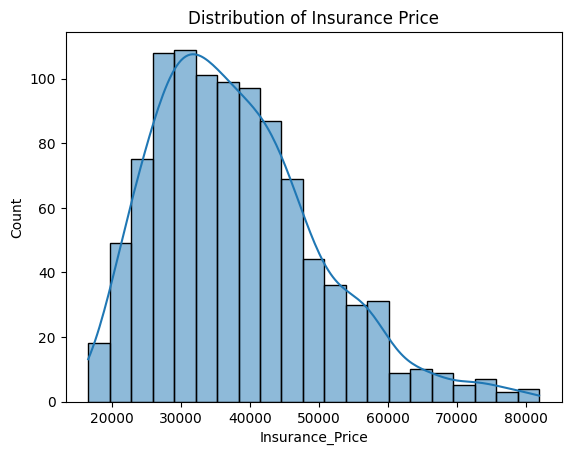

In [26]:
sns.histplot(df['Insurance_Price'], kde=True)
plt.title('Distribution of Insurance Price')
plt.show()

Text(0.5, 1.0, 'Age VS Insurance Price')

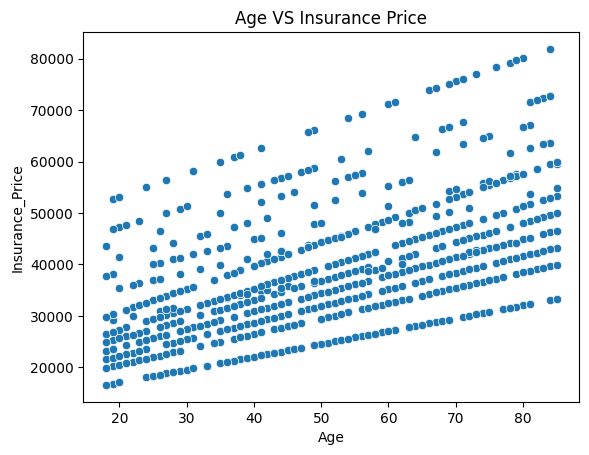

In [28]:
sns.scatterplot(x='Age',y='Insurance_Price',data = df)
plt.title('Age VS Insurance Price')

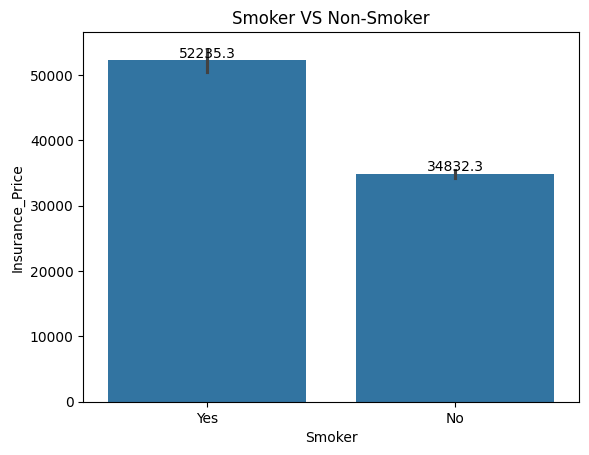

In [33]:
ax=sns.barplot(x='Smoker', y ='Insurance_Price',data = df)
ax.bar_label(ax.containers[0])
plt.title('Smoker VS Non-Smoker')
plt.show()

Text(0.5, 1.0, 'BMI vs Insurance Price')

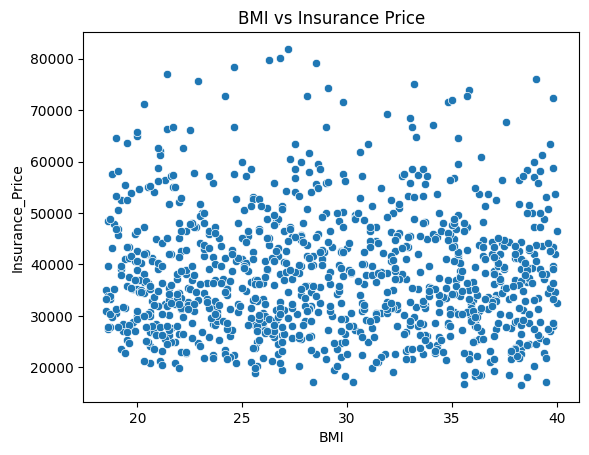

In [50]:
sns.scatterplot(x='BMI',y='Insurance_Price',data=df)
plt.title('BMI vs Insurance Price')

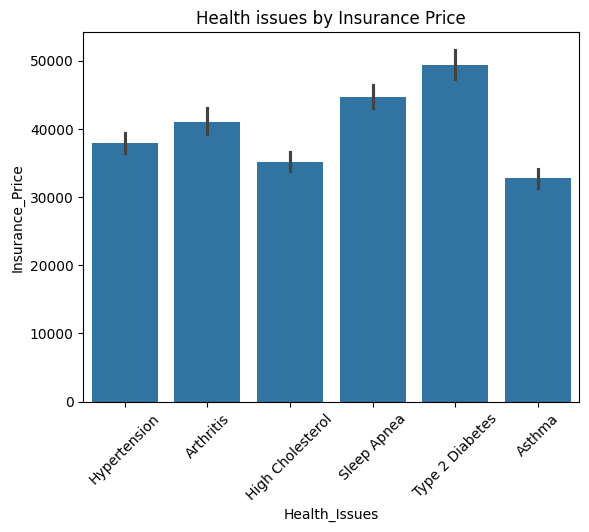

In [48]:
sns.barplot(x='Health_Issues', y = 'Insurance_Price',data=df)
plt.xticks(rotation=45)
plt.title('Health issues by Insurance Price')
plt.show()

<Axes: >

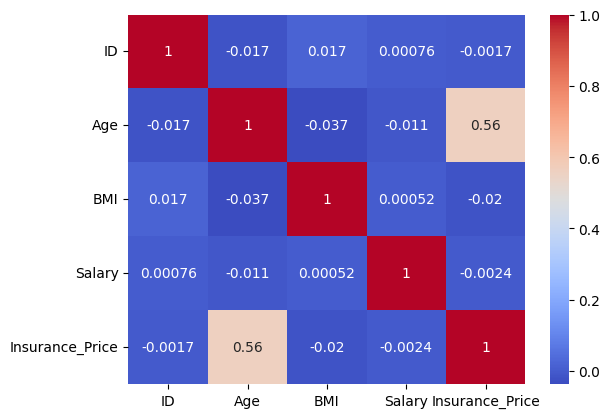

In [43]:
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm')

# Insurance Price Prediction

In [51]:
# Encoding categorical data

gender_encoder = LabelEncoder()
smoker_encoder = LabelEncoder()
health_encoder = LabelEncoder()

df['Gender'] = gender_encoder.fit_transform(df['Gender'])
df['Smoker'] = smoker_encoder.fit_transform(df['Smoker'])
df['Health_Issues'] = health_encoder.fit_transform(df['Health_Issues'])

X = df[['Age','BMI','Health_Issues','Smoker','Salary','Gender']]
y = df['Insurance_Price']

## Train Model

In [52]:
model = LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Prediction Function

In [56]:
def predict_price():

    age = age_scale.get()
    bmi = float(bmi_spinbox.get())

    health = health_listbox.get(health_listbox.curselection())
    if health == "None":
        health = 0
    else:
        health = health_encoder.transform([health])[0]

    smoker = smoker_encoder.transform([smoker_var.get()])[0]

    salary = float(salary_entry.get())

    # Gender Checkbutton Logic
    if male_var.get() == 1:
        gender = "Male"
    elif female_var.get() == 1:
        gender = "Female"
    else:
        result_label.config(text="Select Gender")
        return

    gender = gender_encoder.transform([gender])[0]

    input_data = [[age,bmi,health,smoker,salary,gender]]

    prediction = model.predict(input_data)

    result_label.config(text=f"Predicted Insurance Price: ₹ {round(prediction[0],2)}")

## Tkinter GUI

In [57]:
root = tk.Tk()
root.title("Medical Insurance Price Predictor")
root.geometry("400x520")

# Age Scale
tk.Label(root,text="Age").pack()
age_scale = tk.Scale(root,from_=18,to=80,orient="horizontal")
age_scale.pack()

# BMI Spinbox
tk.Label(root,text="BMI").pack()
bmi_spinbox = tk.Spinbox(root,from_=0,to=40,increment=0.1)
bmi_spinbox.pack()

# Health Issues Listbox
tk.Label(root,text="Health Issues").pack()

health_options = [
"Arthritis",
"Asthma",
"High Cholesterol",
"Hypertension",
"Sleep Apnea",
"Type 2 Diabetes",
"None"
]

health_listbox = tk.Listbox(root,height=7)
for item in health_options:
    health_listbox.insert(tk.END,item)

health_listbox.pack()

# Smoker
tk.Label(root,text="Smoker").pack()

smoker_var = tk.StringVar()
smoker_var = tk.StringVar(value="None")

tk.Radiobutton(root,text="Yes",variable=smoker_var,value="Yes").pack()
tk.Radiobutton(root,text="No",variable=smoker_var,value="No").pack()

# Salary Entry
tk.Label(root,text="Salary").pack()
salary_entry = tk.Entry(root)
salary_entry.pack()

# Gender Checkbuttons
tk.Label(root,text="Gender").pack()

male_var = tk.IntVar()
female_var = tk.IntVar()

tk.Checkbutton(root,text="Male",variable=male_var).pack()
tk.Checkbutton(root,text="Female",variable=female_var).pack()

# Predict Button
tk.Button(root,text="Predict Insurance Price",command=predict_price).pack(pady=10)

# Result Label
result_label = tk.Label(root,text="")
result_label.pack()

root.mainloop()

C:\Users\FAROOQUI\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
